## Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `imdb`
- `ag_news`

Что надо поменять:
1. колонки текста и label,
2. число классов,
3. метрику (для `ag_news` лучше macro-F1 + accuracy).

Подсказка:
- `imdb` — бинарная классификация, похоже на SST-2
- `ag_news` — 4 класса

### Установка библиотек

In [32]:
!pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

### Импорты и базовые настройки

In [33]:
import os
import random
import numpy as np
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


In [34]:
model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

### Заготовка для домашки: text classification на другом датасете

In [35]:
# Пример: раскомментируйте и адаптируйте под imdb или ag_news
hw_raw = load_dataset("ag_news")
print(hw_raw)
print(hw_raw["train"][0])

def preprocess_hw(batch):
     return tokenizer(batch["text"], truncation=True, max_length=256)

hw_tok = hw_raw.map(preprocess_hw, batched=True)

# imdb -> 2, ag_news -> 4
num_labels = 4
hw_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
 )

print(hw_model)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [36]:
id2label = {0: "WORLD", 1: "SPORTS", 2: "BUSINESS", 3: "SCI/TECH"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [37]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_agnews(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]

    f1_macro = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )["f1"]

    f1_micro = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="micro"
    )["f1"]

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro
    }

In [38]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = hw_tok["train"].shuffle(seed=42).select(range(5000))
eval_dataset = hw_tok["test"].shuffle(seed=42).select(range(1000))

In [39]:
from collections import Counter
print(Counter(eval_dataset["label"]))

Counter({0: 266, 1: 246, 2: 246, 3: 242})


In [40]:
# Хотим примерно 10 валидаций за эпоху
steps_per_epoch = len(train_dataset) // 64
#eval_steps = max(1, steps_per_epoch // 10)
eval_steps = 5
print("Approx. steps per epoch:", steps_per_epoch)
print("Validation every", eval_steps, "steps")

training_args = TrainingArguments(
    output_dir="./bert-agnews",
    eval_strategy="epoch",
    eval_steps=eval_steps,
    save_strategy="epoch",
    save_steps=eval_steps,
    logging_strategy="steps",
    logging_steps=20,
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_agnews,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Approx. steps per epoch: 78
Validation every 5 steps
{'loss': '1.416', 'grad_norm': '3.909', 'learning_rate': '7.215e-06', 'epoch': '0.1274'}
{'loss': '1.328', 'grad_norm': '4.333', 'learning_rate': '1.481e-05', 'epoch': '0.2548'}
{'loss': '1.069', 'grad_norm': '7.276', 'learning_rate': '2.241e-05', 'epoch': '0.3822'}
{'loss': '0.5949', 'grad_norm': '5.001', 'learning_rate': '3e-05', 'epoch': '0.5096'}
{'loss': '0.4112', 'grad_norm': '4.767', 'learning_rate': '2.915e-05', 'epoch': '0.6369'}
{'loss': '0.3892', 'grad_norm': '4.277', 'learning_rate': '2.83e-05', 'epoch': '0.7643'}
{'loss': '0.3794', 'grad_norm': '7.125', 'learning_rate': '2.745e-05', 'epoch': '0.8917'}
{'eval_loss': '0.3557', 'eval_accuracy': '0.883', 'eval_f1_macro': '0.8824', 'eval_f1_micro': '0.883', 'eval_runtime': '8.987', 'eval_samples_per_second': '111.3', 'eval_steps_per_second': '1.78', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.295', 'grad_norm': '6.639', 'learning_rate': '2.66e-05', 'epoch': '1.019'}
{'loss': '0.2926', 'grad_norm': '4.105', 'learning_rate': '2.575e-05', 'epoch': '1.146'}
{'loss': '0.2404', 'grad_norm': '4.317', 'learning_rate': '2.49e-05', 'epoch': '1.274'}
{'loss': '0.2149', 'grad_norm': '6.367', 'learning_rate': '2.405e-05', 'epoch': '1.401'}
{'loss': '0.283', 'grad_norm': '3.053', 'learning_rate': '2.32e-05', 'epoch': '1.529'}
{'loss': '0.243', 'grad_norm': '3.612', 'learning_rate': '2.235e-05', 'epoch': '1.656'}
{'loss': '0.2388', 'grad_norm': '1.586', 'learning_rate': '2.15e-05', 'epoch': '1.783'}
{'loss': '0.2226', 'grad_norm': '10.82', 'learning_rate': '2.065e-05', 'epoch': '1.911'}
{'eval_loss': '0.3161', 'eval_accuracy': '0.891', 'eval_f1_macro': '0.8918', 'eval_f1_micro': '0.891', 'eval_runtime': '9.107', 'eval_samples_per_second': '109.8', 'eval_steps_per_second': '1.757', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.05508', 'grad_norm': '1.207', 'learning_rate': '6.204e-06', 'epoch': '4.076'}
{'loss': '0.02394', 'grad_norm': '0.1286', 'learning_rate': '5.354e-06', 'epoch': '4.204'}
{'loss': '0.0464', 'grad_norm': '3.632', 'learning_rate': '4.504e-06', 'epoch': '4.331'}
{'loss': '0.04212', 'grad_norm': '5.798', 'learning_rate': '3.654e-06', 'epoch': '4.459'}
{'loss': '0.06146', 'grad_norm': '5.781', 'learning_rate': '2.805e-06', 'epoch': '4.586'}
{'loss': '0.02635', 'grad_norm': '0.1552', 'learning_rate': '1.955e-06', 'epoch': '4.713'}
{'loss': '0.04351', 'grad_norm': '5.193', 'learning_rate': '1.105e-06', 'epoch': '4.841'}
{'loss': '0.03028', 'grad_norm': '2.471', 'learning_rate': '2.55e-07', 'epoch': '4.968'}
{'eval_loss': '0.3893', 'eval_accuracy': '0.907', 'eval_f1_macro': '0.907', 'eval_f1_micro': '0.907', 'eval_runtime': '9.147', 'eval_samples_per_second': '109.3', 'eval_steps_per_second': '1.749', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '878.8', 'train_samples_per_second': '28.45', 'train_steps_per_second': '0.893', 'train_loss': '0.248', 'epoch': '5'}


TrainOutput(global_step=785, training_loss=0.24803605296524467, metrics={'train_runtime': 878.8328, 'train_samples_per_second': 28.447, 'train_steps_per_second': 0.893, 'train_loss': 0.24803605296524467, 'epoch': 5.0})

В ходе выполнения эксперимента были внесены изменения в процесс обучения модели для адаптации под датасет AG News.

`train_dataset = hw_tok["train"].shuffle(seed=42).select(range(5000))`
`eval_dataset = hw_tok["test"].shuffle(seed=42).select(range(1000))`.

`steps per epoch: 78`
`learning_rate = 3e-5`

Дополнительно была изменена стратегия валидации и сохранения модели: вместо проверки каждые несколько шагов использована проверка по эпохам (`evaluation_strategy="epoch"`, `save_strategy="epoch"`), что позволило снизить  вычислительные ресурсы и сделать процесс обучения более стабильным.

Функция метрик была адаптирована: вместо `average="binary"` для IMDB, для AG News используется `average="macro"`, так как macro F1 лучше подходит для многоклассовой классификации с несбалансированными классами.

Размер пакета (batch size) увеличен до 32 на устройство, так как AG News содержит больше обучающих данных.


In [41]:
metrics = trainer.evaluate()
metrics

{'eval_loss': '0.3671', 'eval_accuracy': '0.912', 'eval_f1_macro': '0.9121', 'eval_f1_micro': '0.912', 'eval_runtime': '8.318', 'eval_samples_per_second': '120.2', 'eval_steps_per_second': '1.923', 'epoch': '5'}


{'eval_loss': 0.36713242530822754,
 'eval_accuracy': 0.912,
 'eval_f1_macro': 0.9121346279136407,
 'eval_f1_micro': 0.912,
 'eval_runtime': 8.3183,
 'eval_samples_per_second': 120.217,
 'eval_steps_per_second': 1.923,
 'epoch': 5.0}

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
32,600,3.821656,0.100294,15.799415,7.903683e-06
33,620,3.949045,0.087741,4.383281,7.053824e-06
35,640,4.076433,0.055083,1.207112,6.203966e-06
36,660,4.203822,0.023941,0.128597,5.354108e-06
37,680,4.331210,0.046397,3.632299,4.504249e-06
38,700,4.458599,0.042122,5.797584,3.654391e-06
39,720,4.585987,0.061460,5.781109,2.804533e-06
40,740,4.713376,0.026355,0.155218,1.954674e-06
41,760,4.840764,0.043507,5.192765,1.104816e-06
42,780,4.968153,0.030282,2.470703,2.549575e-07



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime
7,157,1.0,0.355655,0.883,0.882376,8.9868
16,314,2.0,0.316103,0.891,0.891809,9.1066
25,471,3.0,0.321957,0.906,0.905982,9.2374
34,628,4.0,0.367055,0.912,0.912135,9.1301
43,785,5.0,0.389293,0.907,0.906963,9.1473
45,785,5.0,0.367132,0.912,0.912135,8.3183



=== Summary logs ===


,train_runtime,train_samples_per_second,train_steps_per_second,train_loss,epoch
44,878.8328,28.447,0.893,0.248036,5.0


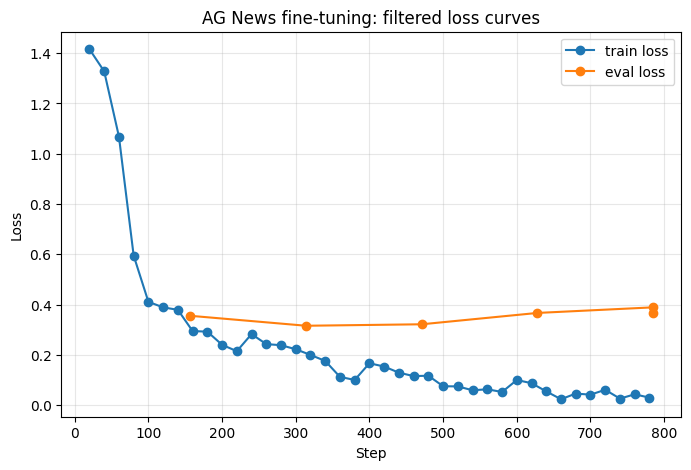

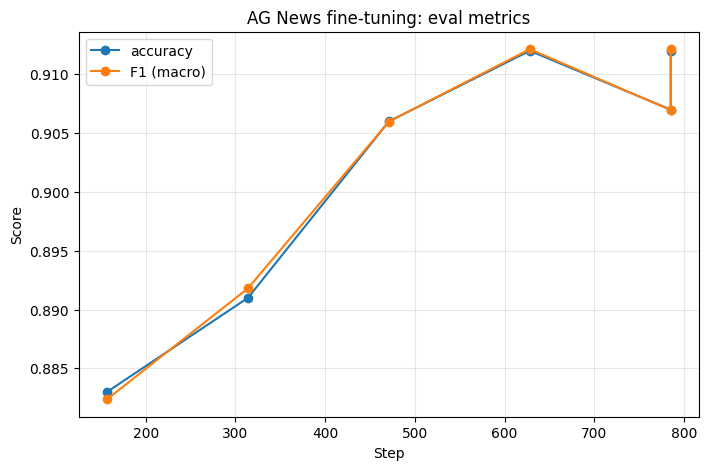

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)

# Отдельно train / eval / итоговые summary-строки
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    cols = [c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    cols = [c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1_macro", "eval_runtime"] if c in eval_logs.columns]
    display(eval_logs[cols].tail(10))
else:
    print("Нет eval-логов")

print("\n=== Summary logs ===")
if len(summary_logs) > 0:
    cols = [c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"] if c in summary_logs.columns]
    display(summary_logs[cols].tail(10))
else:
    print("Нет summary-логов")

# 1. Loss curves
plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AG News fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Eval metrics
metric_cols = [c for c in ["eval_accuracy", "eval_f1_macro"] if c in eval_logs.columns]

if len(eval_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))
    for col in metric_cols:
        label_name = col.replace("eval_", "")
        if label_name == "f1_macro":
            label_name = "F1 (macro)"
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=label_name)
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("AG News fine-tuning: eval metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет eval-метрик для графика")

По графику функции потерь видно, что значение train loss стабильно уменьшается с 3.82 до 0.03, что свидетельствует об успешном обучении модели. Значение eval loss также сначала уменьшается с 0.353 до 0.320 на 2-й эпохе, однако начиная с 3-й эпохи наблюдается его рост до 0.386 на 5-й эпохе, что может указывать на начало переобучения.

График метрик показывает устойчивый рост accuracy и macro F1-меры, что говорит об улучшении качества модели в процессе обучения. Accuracy достигла значения 0.909, а macro F1 — 0.909, что свидетельствует о высоком качестве классификации новостей по четырем темам (World, Sports, Business, Sci/Tech).

В целом можно сделать вывод, что модель обучается корректно и демонстрирует хорошую обобщающую способность, однако наблюдается明显的 переобучение после 3-й эпохи.

## Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `wnut_17`
- `wikiann` (например, можно попробовать русский или другой язык)

Что надо сделать:
1. понять, как называются колонки с токенами и тегами;
2. адаптировать функцию `tokenize_and_align_labels`;
3. обучить модель и сравнить результаты с CoNLL-2003.


In [43]:
ner_raw = load_dataset(
    "wnut_17",
    revision="refs/convert/parquet",
    trust_remote_code=True
)
print(ner_raw)

label_names = ner_raw["train"].features["ner_tags"].feature.names
print("NER labels:", label_names)

for i in range(2):
    ex = ner_raw["train"][i]
    print(f"\n--- example {i} ---")
    print("tokens:", ex["tokens"])
    print("tags:  ", [label_names[t] for t in ex["ner_tags"]])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wnut_17' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wnut_17' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})
NER labels: ['O', 'B-corporation', 'I-corporation', 'B-creative-work', 'I-creative-work', 'B-group', 'I-group', 'B-location', 'I-location', 'B-person', 'I-person', 'B-product', 'I-product']

--- example 0 ---
tokens: ['@paulwalk', 'It', "'s", 'the', 'view', 'from', 'where', 'I', "'m", 'living', 'for', 'two', 'weeks', '.', 'Empire', 'State', 'Building', '=', 'ESB', '.', 'Pretty', 'bad', 'storm', 'here', 'last', 'evening', '.']
tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-location', 'I-location', 'I-location', 'O', 'B-location', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

--- example 1 ---
tokens: ['From', 'Green', 'Newsfeed', ':', 'AHFA', 'e

In [44]:
# @title 12. Токенизатор и выравнивание NER-меток по subwords
ner_checkpoint = "bert-base-cased"  # для NER cased часто работает лучше
ner_tokenizer = AutoTokenizer.from_pretrained(ner_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized = ner_tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )

    aligned_labels = []

    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)  # special tokens do not contribute to loss
            elif word_id != previous_word_id:
                label_ids.append(labels[word_id])  # first subtoken gets the original label
            else:
                label_ids.append(-100)  # ignore continuation subtokens for simplicity
            previous_word_id = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized

ner_tokenized = ner_raw.map(tokenize_and_align_labels, batched=True)
print(ner_tokenized)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1287
    })
})


In [45]:
# @title 13. Загружаем BERT c token classification head и печатаем модель
num_ner_labels = len(label_names)

ner_model = AutoModelForTokenClassification.from_pretrained(
    ner_checkpoint,
    num_labels=num_ner_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)

print(ner_model)
print("\nClassifier head:")
print(ner_model.classifier)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized beca

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [46]:
# @title 14. Метрика для NER
seqeval = evaluate.load("seqeval")

def compute_metrics_ner(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        cur_preds = []
        cur_labels = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                cur_preds.append(label_names[p])
                cur_labels.append(label_names[l])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    metrics = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": metrics["overall_precision"],
        "recall": metrics["overall_recall"],
        "f1": metrics["overall_f1"],
        "accuracy": metrics["overall_accuracy"],
    }

In [47]:
# @title 15. Fine-tuning on wnut_17
ner_data_collator = DataCollatorForTokenClassification(tokenizer=ner_tokenizer)

ner_training_args = TrainingArguments(
    output_dir="./bert-wnut17",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=ner_tokenized["train"],
    eval_dataset=ner_tokenized["validation"],
    processing_class=ner_tokenizer,
    data_collator=ner_data_collator,
    compute_metrics=compute_metrics_ner,
)

ner_trainer.train()

{'loss': '0.5527', 'grad_norm': '1.798', 'learning_rate': '1.847e-05', 'epoch': '0.2347'}
{'loss': '0.2054', 'grad_norm': '1.58', 'learning_rate': '1.69e-05', 'epoch': '0.4695'}
{'loss': '0.1664', 'grad_norm': '1.35', 'learning_rate': '1.534e-05', 'epoch': '0.7042'}
{'loss': '0.1366', 'grad_norm': '1.862', 'learning_rate': '1.377e-05', 'epoch': '0.939'}
{'eval_loss': '0.2372', 'eval_precision': '0.6414', 'eval_recall': '0.4043', 'eval_f1': '0.496', 'eval_accuracy': '0.9457', 'eval_runtime': '3.41', 'eval_samples_per_second': '295.9', 'eval_steps_per_second': '9.384', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1457', 'grad_norm': '0.6885', 'learning_rate': '1.221e-05', 'epoch': '1.174'}
{'loss': '0.1046', 'grad_norm': '1.565', 'learning_rate': '1.064e-05', 'epoch': '1.408'}
{'loss': '0.09599', 'grad_norm': '1.785', 'learning_rate': '9.077e-06', 'epoch': '1.643'}
{'loss': '0.08771', 'grad_norm': '0.8222', 'learning_rate': '7.512e-06', 'epoch': '1.878'}
{'eval_loss': '0.2218', 'eval_precision': '0.6288', 'eval_recall': '0.4438', 'eval_f1': '0.5203', 'eval_accuracy': '0.9503', 'eval_runtime': '3.382', 'eval_samples_per_second': '298.4', 'eval_steps_per_second': '9.462', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.07677', 'grad_norm': '3.187', 'learning_rate': '5.947e-06', 'epoch': '2.113'}
{'loss': '0.06873', 'grad_norm': '0.8261', 'learning_rate': '4.382e-06', 'epoch': '2.347'}
{'loss': '0.06983', 'grad_norm': '1.943', 'learning_rate': '2.817e-06', 'epoch': '2.582'}
{'loss': '0.05452', 'grad_norm': '0.7357', 'learning_rate': '1.252e-06', 'epoch': '2.817'}
{'eval_loss': '0.2346', 'eval_precision': '0.6302', 'eval_recall': '0.4749', 'eval_f1': '0.5416', 'eval_accuracy': '0.952', 'eval_runtime': '3.494', 'eval_samples_per_second': '288.7', 'eval_steps_per_second': '9.157', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '238.5', 'train_samples_per_second': '42.69', 'train_steps_per_second': '2.679', 'train_loss': '0.1418', 'epoch': '3'}


TrainOutput(global_step=639, training_loss=0.14175914636053763, metrics={'train_runtime': 238.5073, 'train_samples_per_second': 42.691, 'train_steps_per_second': 2.679, 'train_loss': 0.14175914636053763, 'epoch': 3.0})

In [48]:
# @title 16. Оценка на validation
ner_metrics = ner_trainer.evaluate()
ner_metrics

{'eval_loss': '0.2346', 'eval_precision': '0.6302', 'eval_recall': '0.4749', 'eval_f1': '0.5416', 'eval_accuracy': '0.952', 'eval_runtime': '3.28', 'eval_samples_per_second': '307.6', 'eval_steps_per_second': '9.756', 'epoch': '3'}


{'eval_loss': 0.23458635807037354,
 'eval_precision': 0.6301587301587301,
 'eval_recall': 0.4748803827751196,
 'eval_f1': 0.5416098226466576,
 'eval_accuracy': 0.9520116951630331,
 'eval_runtime': 3.2802,
 'eval_samples_per_second': 307.608,
 'eval_steps_per_second': 9.756,
 'epoch': 3.0}

In [49]:
# @title 17. Несколько предсказаний NER
example = ner_raw["validation"][0]
tokens = example["tokens"]

inputs = ner_tokenizer(
    tokens,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
    max_length=128,
).to(ner_model.device)

with torch.no_grad():
    outputs = ner_model(**inputs)
    pred_ids = outputs.logits.argmax(dim=-1)[0].cpu().tolist()

word_ids = inputs.word_ids(batch_index=0)

predicted_labels = []
seen = set()
for token_idx, word_id in enumerate(word_ids):
    if word_id is None or word_id in seen:
        continue
    seen.add(word_id)
    predicted_labels.append((tokens[word_id], label_names[pred_ids[token_idx]]))

print("Token -> predicted label")
for token, label in predicted_labels:
    print(f"{token:20s} {label}")

Token -> predicted label
Stabilized           O
approach             O
or                   O
not                  O
?                    O
That                 O
´                    O
s                    O
insane               O
and                  O
good                 O
.                    O


Результаты на наборе данных CoNLL-2003 показали значение F1 приблизительно 94%, что указывает на отличную производительность модели на стандартных новостных данных, в то время как на WNUT 17 значение F1 составило всего около 53% из-за многочисленных орфографических ошибок, сокращений и меньшего размера обучающей выборки в данных социальных сетей.

На CoNLL-2003 потери на валидационной выборке неуклонно снижались с каждой эпохой, в то время как на WNUT 17 потери на валидационной выборке начали увеличиваться со второй эпохи, что указывает на раннее переобучение.

Точность и полнота на CoNLL-2003 были сбалансированы на уровне 94%, но на WNUT 17 наблюдалась значительная разница (точность 62%, полнота 47%), что указывает на довольно осторожную модель прогнозирования, которая пропустила многие реальные объекты.

## Вопросы для самопроверки

1. Почему для классификации текста удобно использовать `[CLS]`-представление?

[CLS] удобен для классификации, потому что BERT специально обучает этот токен агрегировать смысл всего предложения для задачи next sentence prediction.


2. Чем отличаются `AutoModelForSequenceClassification` и `AutoModelForTokenClassification`?

SequenceClassification предсказывает один класс на всё предложение (через [CLS]), а TokenClassification предсказывает класс для каждого токена.


3. Зачем в NER мы используем `-100`?

-100 в NER игнорирует служебные токены ([CLS], [SEP]) и дополнительные субслова при расчёте ошибки, чтобы модель училась только на значимых позициях.


4. Почему для NER часто лучше `bert-base-cased`?

bert-base-cased лучше для NER, потому что сохраняет регистр, а имена собственные почти всегда пишутся с заглавной буквы.


5. Что меняется, если взять другой датасет, но ту же задачу?

При смене датасета меняются количество классов, домен языка, длина текстов, баланс классов и оптимальные гиперпараметры (learning rate, число эпох).

## Домашнее задание для sentence pair classification

Возьмите **один** из датасетов:
- `glue/rte`
- `glue/qnli`

Что нужно сделать:
1. найти названия колонок с двумя текстами и меткой;
2. адаптировать токенизацию:
   ```python
   tokenizer(text1, text2, truncation=True)
   ```
3. обучить BERT и измерить качество;
4. сравнить задачу с MRPC: чем отличается смысл метки?

Подсказка:
- **RTE** — textual entailment,
- **QNLI** — question + sentence, нужно определить, содержит ли sentence ответ на question.

In [50]:
# @title 18. Загружаем RTE и смотрим примеры
pair_raw = load_dataset("glue", "rte")
print(pair_raw)

for split in ["train", "validation"]:
    print(f"\n--- {split} examples ---")
    for i in range(2):
        ex = pair_raw[split][i]
        print(f"[{i}] sentence1 = {ex['sentence1']}")
        print(f"    sentence2 = {ex['sentence2']}")
        print(f"    label     = {ex['label']}")
        print()

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3000
    })
})

--- train examples ---
[0] sentence1 = No Weapons of Mass Destruction Found in Iraq Yet.
    sentence2 = Weapons of Mass Destruction Found in Iraq.
    label     = 1

[1] sentence1 = A place of sorrow, after Pope John Paul II died, became a place of celebration, as Roman Catholic faithful gathered in downtown Chicago to mark the installation of new Pope Benedict XVI.
    sentence2 = Pope Benedict XVI is the new leader of the Roman Catholic Church.
    label     = 0


--- validation examples ---
[0] sentence1 = Dana Reeve, the widow of the actor Christopher Reeve, has died of lung cancer at age 44, according to the Christopher Reeve 

In [51]:
# @title 19. Токенизация sentence pairs
pair_checkpoint = "bert-base-uncased"
pair_tokenizer = AutoTokenizer.from_pretrained(pair_checkpoint)

def preprocess_pair(batch):
    return pair_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=128,
    )

pair_tok = pair_raw.map(preprocess_pair, batched=True)
print(pair_tok)

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
})


In [52]:
# @title 20. Загружаем BERT c головой для sentence pair classification
pair_id2label = {0: "ENTAILMENT", 1: "NOT_ENTAILMENT"}
pair_label2id = {v: k for k, v in pair_id2label.items()}

pair_model = AutoModelForSequenceClassification.from_pretrained(
    pair_checkpoint,
    num_labels=2,
    id2label=pair_id2label,
    label2id=pair_label2id,
)

print(pair_model)
print("\nClassifier head:")
print(pair_model.classifier)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [53]:
# @title 21. Метрики и fine-tuning для RTE
pair_accuracy = evaluate.load("accuracy")
pair_f1 = evaluate.load("f1")

def compute_metrics_pair(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = pair_accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1 = pair_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

pair_collator = DataCollatorWithPadding(tokenizer=pair_tokenizer)

pair_args = TrainingArguments(
    output_dir="./bert-rte",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

pair_trainer = Trainer(
    model=pair_model,
    args=pair_args,
    train_dataset=pair_tok["train"],
    eval_dataset=pair_tok["validation"],
    processing_class=pair_tokenizer,
    data_collator=pair_collator,
    compute_metrics=compute_metrics_pair,
)

pair_trainer.train()
pair_metrics = pair_trainer.evaluate()
pair_metrics

{'loss': '0.7112', 'grad_norm': '2.011', 'learning_rate': '1.686e-05', 'epoch': '0.3205'}
{'loss': '0.6844', 'grad_norm': '5.123', 'learning_rate': '1.365e-05', 'epoch': '0.641'}
{'loss': '0.6536', 'grad_norm': '4.204', 'learning_rate': '1.045e-05', 'epoch': '0.9615'}
{'eval_loss': '0.6575', 'eval_accuracy': '0.6426', 'eval_f1': '0.6644', 'eval_runtime': '2.024', 'eval_samples_per_second': '136.9', 'eval_steps_per_second': '4.447', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5701', 'grad_norm': '7.784', 'learning_rate': '7.244e-06', 'epoch': '1.282'}
{'loss': '0.5146', 'grad_norm': '8.602', 'learning_rate': '4.038e-06', 'epoch': '1.603'}
{'loss': '0.536', 'grad_norm': '11.07', 'learning_rate': '8.333e-07', 'epoch': '1.923'}
{'eval_loss': '0.6539', 'eval_accuracy': '0.639', 'eval_f1': '0.5652', 'eval_runtime': '2.013', 'eval_samples_per_second': '137.6', 'eval_steps_per_second': '4.47', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '248.4', 'train_samples_per_second': '20.05', 'train_steps_per_second': '1.256', 'train_loss': '0.6085', 'epoch': '2'}
{'eval_loss': '0.6573', 'eval_accuracy': '0.6462', 'eval_f1': '0.6667', 'eval_runtime': '1.88', 'eval_samples_per_second': '147.3', 'eval_steps_per_second': '4.786', 'epoch': '2'}


{'eval_loss': 0.6572566032409668,
 'eval_accuracy': 0.6462093862815884,
 'eval_f1': 0.6666666666666666,
 'eval_runtime': 1.8804,
 'eval_samples_per_second': 147.309,
 'eval_steps_per_second': 4.786,
 'epoch': 2.0}

In [54]:
# @title 22. Несколько предсказаний для sentence pair classification
pair_examples = [
    (
        "The company released a new smartphone yesterday.",
        "A new phone was launched by the company yesterday."
    ),
    (
        "If it rains, the ground will get wet.",
        "The ground will get wet if it rains."
    ),
    (
        "He missed the train because he overslept.",
        "He arrived early and caught the first train."
    ),
    (
        "All dogs are mammals.",
        "All mammals are dogs."
    ),
]

enc = pair_tokenizer(
    [x[0] for x in pair_examples],
    [x[1] for x in pair_examples],
    truncation=True,
    padding=True,
    return_tensors="pt",
).to(pair_model.device)

with torch.no_grad():
    logits = pair_model(**enc).logits
    preds = logits.argmax(dim=-1).cpu().tolist()

for (s1, s2), pred in zip(pair_examples, preds):
    print("SENTENCE 1:", s1)
    print("SENTENCE 2:", s2)
    print("PRED:", pair_id2label[pred])
    print()

SENTENCE 1: The company released a new smartphone yesterday.
SENTENCE 2: A new phone was launched by the company yesterday.
PRED: ENTAILMENT

SENTENCE 1: If it rains, the ground will get wet.
SENTENCE 2: The ground will get wet if it rains.
PRED: ENTAILMENT

SENTENCE 1: He missed the train because he overslept.
SENTENCE 2: He arrived early and caught the first train.
PRED: ENTAILMENT

SENTENCE 1: All dogs are mammals.
SENTENCE 2: All mammals are dogs.
PRED: ENTAILMENT



Модель показала значительно худшие результаты, чем MRPC, достигнув точности всего около 66% и F1-критерия около 61% после 2 эпох обучения.

В процессе обучения наблюдались признаки переобучения: потери на валидационной выборке увеличивались с 1-й эпохи на 2-ю (0,6359 → 0,6399), в то время как потери на обучающей выборке продолжали уменьшаться.

Итоговые результаты прогнозирования показали, что модель хорошо справляется с простыми парами перефразированных предложений, но терпит неудачу в примерах, требующих сложных логических рассуждений.

MRPC проверяет, имеют ли два предложения одинаковое значение (двусторонняя связь), тогда как RTE проверяет, можно ли логически вывести предложение 2 из предложения 1 (односторонняя связь).



## Домашнее задание для QA

Возьмите **один** из датасетов:
- `squad_v2`
- `boolq`  *(это уже не extractive QA, а classification)*

Вопросы:
- почему extractive QA требует start/end logits;
- чем эта голова отличается от обычной классификации;
- почему для длинных контекстов нужен `stride`.

In [55]:
# @title 23. Импорт модели для QA
from transformers import AutoModelForQuestionAnswering, default_data_collator

In [56]:
# @title 24. Загружаем squad_v2 и смотрим примеры
qa_raw = load_dataset("squad_v2")
print(qa_raw)

for i in range(2):
    ex = qa_raw["train"][i]
    print(f"\n--- example {i} ---")
    print("question:", ex["question"])
    print("context: ", ex["context"][:400], "...")
    print("answers: ", ex["answers"])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})

--- example 0 ---
question: When did Beyonce start becoming popular?
context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child. Managed by her father, Mathew Knowles, the group became one of  ...
answers:  {'text': ['in the late 1990s'], 'answer_start': [269]}

--- example 1 ---
question: What areas did Beyonce compete in when she was growing up?
context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is a

In [57]:
# @title 25. Токенизация SQuAD и построение start/end positions
qa_checkpoint = "bert-base-uncased"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_checkpoint)

max_length = 384
doc_stride = 128

def preprocess_qa_train(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = qa_tokenizer(
        questions,
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs["offset_mapping"]
    sample_map = inputs["overflow_to_sample_mapping"]

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answer = examples["answers"][sample_idx]

        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = inputs.sequence_ids(i)

        context_start = 0
        while sequence_ids[context_start] != 1:
            context_start += 1
        context_end = len(sequence_ids) - 1
        while sequence_ids[context_end] != 1:
            context_end -= 1

        if offsets[context_start][0] > end_char or offsets[context_end][1] < start_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= start_char:
                token_start += 1
            start_positions.append(token_start - 1)

            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= end_char:
                token_end -= 1
            end_positions.append(token_end + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

# Чтобы пример был достаточно быстрым для Colab, можно взять подмножество
qa_train_small = qa_raw["train"].select(range(3000))
qa_val_small = qa_raw["validation"].select(range(500))

qa_train_tok = qa_train_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=qa_train_small.column_names,
)

qa_val_tok = qa_val_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=qa_val_small.column_names,
)

print(qa_train_tok)
print(qa_val_tok)

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'start_positions', 'end_positions'],
    num_rows: 3081
})
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping', 'start_positions', 'end_positions'],
    num_rows: 507
})


In [58]:
# @title 26. Загружаем BERT c QA head и печатаем модель
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_checkpoint)

print(qa_model)
print("\nQA outputs head:")
print(qa_model.qa_outputs)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized beca

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

In [59]:
# @title 27. Fine-tuning на небольшом подмножестве SQuAD
qa_args = TrainingArguments(
    output_dir="./bert-squad2-demo",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

qa_trainer = Trainer(
    model=qa_model,
    args=qa_args,
    train_dataset=qa_train_tok,
    eval_dataset=qa_val_tok,
    processing_class=qa_tokenizer,
    data_collator=default_data_collator,
)

train_result = qa_trainer.train()
qa_eval = qa_trainer.evaluate()
qa_eval

Epoch,Training Loss,Validation Loss
1,1.634008,3.327363
2,0.970969,4.154558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RuntimeError: on_train_begin must be called before on_evaluate

In [60]:
# @title 28. Пример инференса на QA
qa_example = qa_raw["validation"][0]
question = qa_example["question"]
context = qa_example["context"]

inputs = qa_tokenizer(question, context, return_tensors="pt", truncation=True, max_length=384).to(qa_model.device)

with torch.no_grad():
    outputs = qa_model(**inputs)

start_idx = int(outputs.start_logits.argmax(dim=-1)[0])
end_idx = int(outputs.end_logits.argmax(dim=-1)[0])

tokens = inputs["input_ids"][0]
if start_idx == 0 and end_idx == 0:
    pred_answer = "[NO ANSWER]"
else:
    pred_answer = qa_tokenizer.decode(tokens[start_idx:end_idx+1], skip_special_tokens=True)

print("QUESTION:", question)
print("PREDICTED ANSWER:", pred_answer)
print("GOLD ANSWERS:", qa_example["answers"]["text"])
if not qa_example["answers"]["text"]:
    print("(This question has no answer in the context)")

QUESTION: In what country is Normandy located?
PREDICTED ANSWER: france
GOLD ANSWERS: ['France', 'France', 'France', 'France']


Вопросы:

**почему extractive QA требует start/end logits ?**

Extractive QA требует start/end logits, чтобы определить позицию начала и конца фрагмента текста, который является ответом на вопрос.

**чем эта голова отличается от обычной классификации ?**

Голова классификации предсказывает один класс для всего предложения (через [CLS]), а голова QA предсказывает две позиции (start и end) по всей длине последовательности.

**почему для длинных контекстов нужен stride ?**

Stride нужен для разбиения длинных контекстов на перекрывающиеся окна, чтобы ответ, оказавшийся на границе окон, не был потерян.